# Econ 521 Lab: Instrumental Variables through the Wald Estimator
### Angrist & Krueger (1991), *Does Compulsory School Attendance Affect Schooling and Earnings?*

**Friday lab · 50 minutes** · companion to Thursday's IV lecture (Mastering 'Metrics ch. 3, Mixtape ch. 7, The Effect ch. 19)

---

**Where we are.** In the RCT labs we *controlled* who got treated, so a simple difference in means was causal. Today we lose that control. We want the causal effect of **schooling** on **earnings**, and nobody can randomize how many years of school a person completes.

**The big idea of today, in one sentence:**
> If we can't randomize the treatment, find something that was (as good as) randomized and that *nudges* the treatment. Then scale the effect of the nudge on the outcome by the effect of the nudge on the treatment.

That ratio is the **Wald estimator**, and it is the simplest instrumental-variables (IV) estimator there is.

**Plan**

| Part | What we do | Time |
|---|---|---|
| 1 | Why OLS fails here: a picture of endogeneity | 5 min |
| 2 | A simulated world where we *know* the answer: OLS vs. Wald | 12 min |
| 3 | Angrist & Krueger (1991): first stage, reduced form, Wald | 18 min |
| 4 | From Wald to 2SLS, and what can go wrong | 12 min |
| 5 | Wrap-up: the four reading-note questions for AK91 | 3 min |

Cells marked **`# TODO`** are yours. Sections marked ⏱ are *if time*; finish them at home.

In [19]:
# Setup ---------------------------------------------------------------
# If needed:  pip install pyreadr linearmodels statsmodels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from linearmodels.iv import IV2SLS



---
## Part 1. The problem: endogeneity in the returns to schooling

Recall potential outcomes. Let $S_i$ be years of schooling and $Y_i$ log weekly wage. We want $\rho$ in

$$Y_i = \alpha + \rho S_i + \eta_i ,$$

where $\eta_i$ collects *everything else* that determines wages: ability, motivation, family background, connections...

OLS recovers $\rho$ only if $S_i$ is uncorrelated with $\eta_i$. But the same things that raise wages (ability, family resources) also make people stay in school longer. So

$$\hat\rho_{OLS} \;\xrightarrow{p}\; \rho + \underbrace{\frac{\text{Cov}(S_i,\eta_i)}{\text{Var}(S_i)}}_{\text{ability / selection bias}}$$

This is the same **selection bias** term from the SDO decomposition in Lab 1, now in regression form. People who chose more schooling are *different* people.

**Panel (a)** below draws this problem as a DAG. **Panel (b)** shows the IV fix: find a variable $Z$ that moves schooling but is unrelated to $U$ and has no other road to wages. Then the *only* way $Z$ can be associated with $Y$ is through $S$.

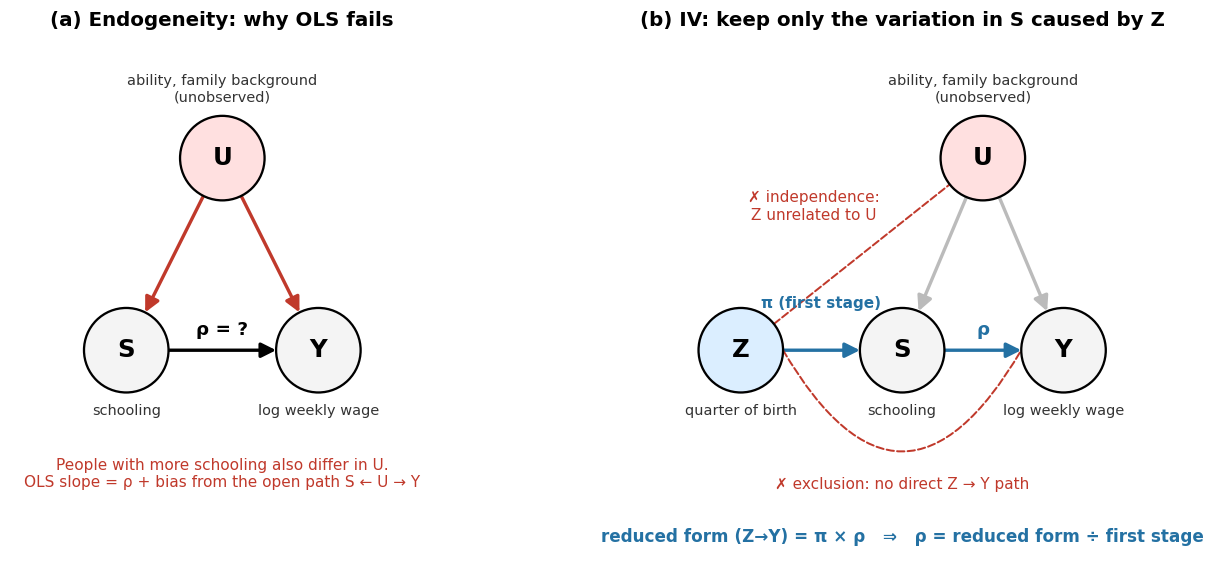

In [2]:
# Figure 1: endogeneity and how IV fixes it (run; you don't need to read the plotting code)
from matplotlib.patches import FancyArrowPatch, Circle
R = 0.11
def node(ax, xy, label, sub, color='#f4f4f4', sub_above=False):
    ax.add_patch(Circle(xy, R, fc=color, ec='black', lw=1.5, zorder=3))
    ax.text(*xy, label, ha='center', va='center', fontsize=16, fontweight='bold', zorder=4)
    if sub_above:
        ax.text(xy[0], xy[1] + R + 0.03, sub, ha='center', va='bottom', fontsize=9.5, color='#333')
    else:
        ax.text(xy[0], xy[1] - R - 0.03, sub, ha='center', va='top', fontsize=9.5, color='#333')
def edge(ax, a, b, color='black', ls='-', lw=2.2, head=True, rad=0.0):
    a, b = np.array(a), np.array(b); d = (b - a) / np.linalg.norm(b - a)
    p, q = a + d * R, b - d * R
    ax.add_patch(FancyArrowPatch(p, q, arrowstyle='-|>' if head else '-', mutation_scale=20,
                 color=color, lw=lw, ls=ls, shrinkA=0, shrinkB=0,
                 connectionstyle=f'arc3,rad={rad}', zorder=2))
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax in axes:
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.22, 1.12); ax.set_aspect('equal'); ax.axis('off')
# (a)
ax = axes[0]; S, Y, U = (0.25, 0.3), (0.75, 0.3), (0.5, 0.8)
node(ax, S, 'S', 'schooling'); node(ax, Y, 'Y', 'log weekly wage')
node(ax, U, 'U', 'ability, family background\n(unobserved)', '#ffe0e0', sub_above=True)
edge(ax, S, Y); ax.text(0.5, 0.34, 'ρ = ?', ha='center', fontsize=12, fontweight='bold')
edge(ax, U, S, color='#c0392b'); edge(ax, U, Y, color='#c0392b')
ax.set_title('(a) Endogeneity: why OLS fails', fontsize=13, fontweight='bold')
ax.text(0.5, 0.02, 'People with more schooling also differ in U.\nOLS slope = ρ + bias from the open path S ← U → Y',
        ha='center', va='top', fontsize=10, color='#c0392b')
# (b)
ax = axes[1]; Z, S, Y, U = (0.08, 0.3), (0.5, 0.3), (0.92, 0.3), (0.71, 0.8)
node(ax, Z, 'Z', 'quarter of birth', '#dbeeff'); node(ax, S, 'S', 'schooling'); node(ax, Y, 'Y', 'log weekly wage')
node(ax, U, 'U', 'ability, family background\n(unobserved)', '#ffe0e0', sub_above=True)
edge(ax, Z, S, color='#2471a3'); ax.text(0.29, 0.41, 'π (first stage)', ha='center', fontsize=10, color='#2471a3', fontweight='bold')
edge(ax, S, Y, color='#2471a3'); ax.text(0.71, 0.34, 'ρ', ha='center', fontsize=12, color='#2471a3', fontweight='bold')
edge(ax, U, S, color='#bbbbbb'); edge(ax, U, Y, color='#bbbbbb')
edge(ax, Z, Y, color='#c0392b', ls='--', lw=1.3, head=False, rad=0.85)
ax.text(0.5, -0.06, '✗ exclusion: no direct Z → Y path', color='#c0392b', ha='center', fontsize=10)
edge(ax, Z, U, color='#c0392b', ls='--', lw=1.3, head=False)
ax.text(0.27, 0.64, '✗ independence:\nZ unrelated to U', color='#c0392b', ha='center', fontsize=10)
ax.set_title('(b) IV: keep only the variation in S caused by Z', fontsize=13, fontweight='bold')
ax.text(0.5, -0.2, 'reduced form (Z→Y) = π × ρ   ⇒   ρ = reduced form ÷ first stage',
        ha='center', fontsize=11, color='#2471a3', fontweight='bold')
plt.tight_layout(); plt.show()

**Read panel (b) as an accounting identity.** If $Z$ has no direct path to $Y$ and no link to $U$, then

- the effect of $Z$ on $S$ is the **first stage**, $\pi$;
- the effect of $Z$ on $Y$ is the **reduced form**; it must equal $\pi \times \rho$, since $S$ is the only channel.

So $\rho = \dfrac{\text{reduced form}}{\text{first stage}}$. Everything else today is this one line.

With a **binary** instrument, both effects are just differences in means, and we get the **Wald estimator** (Wald, 1940):

$$
\boxed{\;\hat\rho_{Wald} \;=\; \frac{\bar Y_{Z=1} - \bar Y_{Z=0}}{\bar S_{Z=1} - \bar S_{Z=0}}\;}
$$

> **Intuition check.** Suppose people with $Z=1$ earn 1% more and have 0.1 more years of schooling. If schooling is the *only* reason they earn more, then 0.1 years is "worth" 1%, so one year is worth 10%.

This is exactly the calculation on the lecture slides for Card's college-proximity instrument: $0.0619 / 0.360 \approx 0.17$.

---
## Part 2. A world where we know the truth

Before touching real data, let's build a data-generating process (DGP) where the true return to schooling is **8%** and ability is an unobserved confounder.

$$
\begin{aligned}
U_i &\sim N(0,1) && \text{(ability, unobserved)}\\
Z_i &\sim \text{Bernoulli}(0.5) && \text{(the instrument: a coin flip)}\\
S_i &= 12 + \pi Z_i + 1.5\,U_i + v_i && \text{(first stage)}\\
Y_i &= 1 + \rho S_i + 0.15\,U_i + \gamma Z_i + e_i && \text{(outcome; } \rho = 0.08,\ \gamma = 0 \text{ unless we break it)}
\end{aligned}
$$

Ability raises schooling *and* wages, so OLS should be biased upward. $\gamma$ is a direct effect of $Z$ on $Y$; the exclusion restriction says $\gamma = 0$.

In [3]:
def simulate(n=20_000, pi=1.0, rho=0.08, gamma=0.0, seed=521):
    rng = np.random.default_rng(seed)
    U = rng.normal(0, 1, n)
    Z = rng.binomial(1, 0.5, n)
    S = 12 + pi * Z + 1.5 * U + rng.normal(0, 1.5, n)
    Y = 1.0 + rho * S + 0.15 * U + gamma * Z + rng.normal(0, 0.4, n)
    return pd.DataFrame({"U": U, "Z": Z, "S": S, "Y": Y})

sim = simulate()
sim.head()

,U,Z,S,Y
0,0.3904,0,9.6889,2.1337
1,-0.0937,0,13.4925,2.3529
2,-2.2940,0,8.5992,1.7789
3,0.9690,1,15.1009,2.6810
4,-1.3977,1,11.1156,1.6131


### Exercise 2.1: OLS and the Wald estimator

1. Regress $Y$ on $S$ by OLS. Is it close to 0.08?
2. Compute the four group means and the Wald estimator by hand.

In [4]:
# 1. OLS
ols_sim = smf.ols("Y ~ S", data=sim).fit()
b_ols_sim = ols_sim.params["S"]

# 2. Wald by hand
means = sim.groupby("Z")[["S", "Y"]].mean()
first_stage   = means.loc[1, "S"] - means.loc[0, "S"]
reduced_form  = means.loc[1, "Y"] - means.loc[0, "Y"]
wald_sim      = reduced_form / first_stage

print(f"True rho       : 0.0800")
print(f"OLS            : {b_ols_sim:.4f}")
print(f"First stage    : {first_stage:.4f} years")
print(f"Reduced form   : {reduced_form:.4f} log points")
print(f"Wald = RF / FS : {wald_sim:.4f}")

True rho       : 0.0800
OLS            : 0.1277
First stage    : 1.0266 years
Reduced form   : 0.0851 log points
Wald = RF / FS : 0.0829


**Checkpoint.** Can you derive the OLS number *before* running the code? The bias is $\text{Cov}(S,\,0.15U)/\text{Var}(S) = 0.15\times1.5 \,/\, (0.25 + 2.25 + 2.25)$. Work it out; it should match.

### Figure 2: how IV fixes it

The left panel is what OLS sees: a cloud where high-$S$ people are also high-$U$ people, so the fitted line is too steep. The right panel is what the Wald estimator sees: **only two points**, the average person with $Z=0$ and the average person with $Z=1$. Because $Z$ is a coin flip, these two groups have the *same* average ability; they differ in schooling only because of $Z$. The slope of the line joining them is the Wald estimate.

This is literally the title of Wald's 1940 paper: *"The fitting of straight lines if both variables are subject to error."*

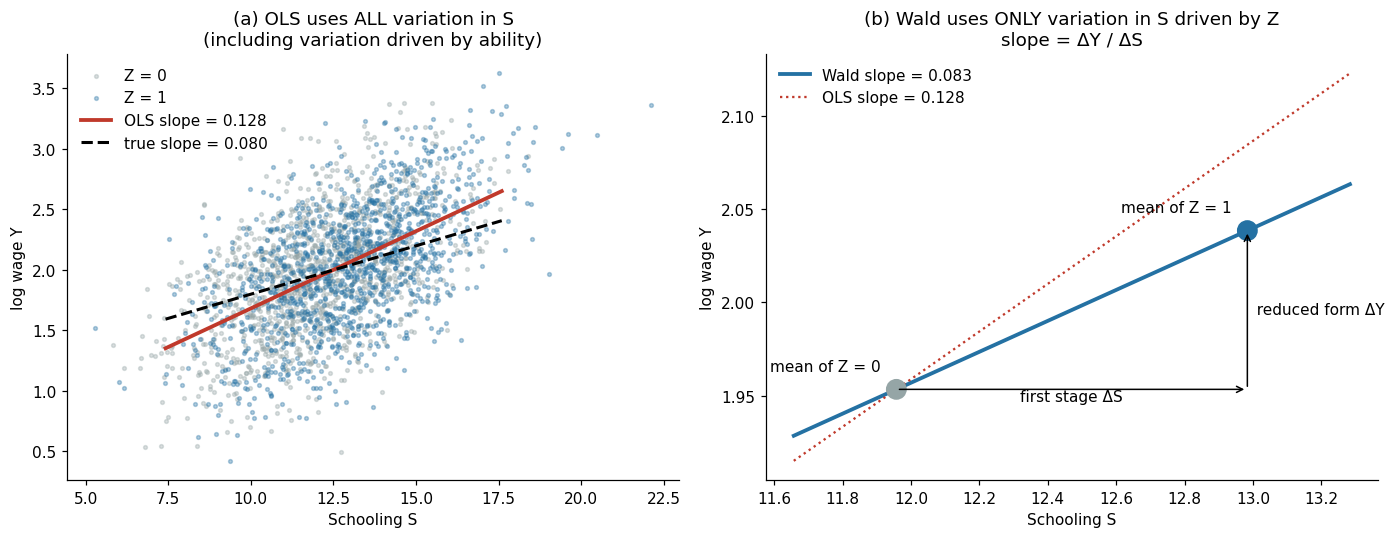

In [5]:
def plot_ols_vs_wald(df, rho_true=0.08, n_show=2500, seed=1):
    pts = df.sample(n_show, random_state=seed)
    m = df.groupby("Z")[["S", "Y"]].mean()
    b_ols = smf.ols("Y ~ S", data=df).fit().params
    wald = (m.loc[1, "Y"] - m.loc[0, "Y"]) / (m.loc[1, "S"] - m.loc[0, "S"])
    xbar, ybar = df.S.mean(), df.Y.mean()

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    # (a) what OLS sees
    for z, c in [(0, "#95a5a6"), (1, "#2471a3")]:
        p = pts[pts.Z == z]
        ax[0].scatter(p.S, p.Y, s=6, alpha=0.35, color=c, label=f"Z = {z}")
    xs = np.linspace(df.S.quantile(.01), df.S.quantile(.99), 50)
    ax[0].plot(xs, b_ols["Intercept"] + b_ols["S"] * xs, color="#c0392b", lw=2.5,
               label=f"OLS slope = {b_ols['S']:.3f}")
    ax[0].plot(xs, ybar + rho_true * (xs - xbar), "k--", lw=2, label=f"true slope = {rho_true:.3f}")
    ax[0].set(xlabel="Schooling S", ylabel="log wage Y", title="(a) OLS uses ALL variation in S\n(including variation driven by ability)")
    ax[0].legend(frameon=False, loc="upper left")

    # (b) what the Wald estimator sees
    ax[1].scatter(m.S, m.Y, s=160, color=["#95a5a6", "#2471a3"], zorder=3)
    ax[1].annotate("mean of Z = 0", (m.loc[0, "S"], m.loc[0, "Y"]), xytext=(-10, 12), textcoords="offset points", ha="right", fontsize=10)
    ax[1].annotate("mean of Z = 1", (m.loc[1, "S"], m.loc[1, "Y"]), xytext=(-10, 12), textcoords="offset points", ha="right", fontsize=10)
    xs2 = np.linspace(m.S.min() - 0.3, m.S.max() + 0.3, 20)
    ax[1].plot(xs2, m.loc[0, "Y"] + wald * (xs2 - m.loc[0, "S"]), color="#2471a3", lw=2.5, label=f"Wald slope = {wald:.3f}")
    ax[1].plot(xs2, m.loc[0, "Y"] + b_ols["S"] * (xs2 - m.loc[0, "S"]), color="#c0392b", lw=1.5, ls=":", label=f"OLS slope = {b_ols['S']:.3f}")
    # first stage and reduced form as legs of a triangle
    ax[1].annotate("", xy=(m.loc[1, "S"], m.loc[0, "Y"]), xytext=(m.loc[0, "S"], m.loc[0, "Y"]),
                   arrowprops=dict(arrowstyle="->", color="k"))
    ax[1].annotate("", xy=(m.loc[1, "S"], m.loc[1, "Y"]), xytext=(m.loc[1, "S"], m.loc[0, "Y"]),
                   arrowprops=dict(arrowstyle="->", color="k"))
    ax[1].text(m.S.mean(), m.loc[0, "Y"], "first stage ΔS\n", ha="center", va="top", fontsize=10)
    ax[1].text(m.loc[1, "S"], m.Y.mean(), "  reduced form ΔY", va="center", fontsize=10)
    ax[1].set(xlabel="Schooling S", ylabel="log wage Y", title="(b) Wald uses ONLY variation in S driven by Z\nslope = ΔY / ΔS")
    ax[1].legend(frameon=False, loc="upper left")
    plt.tight_layout(); plt.show()

plot_ols_vs_wald(sim)

### Exercise 2.2: break the exclusion restriction

Now let $Z$ affect wages directly by $\gamma = 0.02$ (2%), for example because the coin flip also gives some people a better job network.

**Before running the code**, write down your prediction. Hint: the reduced form now equals $\pi\rho + \gamma$, so the Wald estimator converges to $\rho + \gamma/\pi$.

Then repeat with a much weaker first stage, $\pi = 0.25$. What happens to the same 2% violation?

In [6]:
def wald(df):
    m = df.groupby("Z")[["S", "Y"]].mean()
    return (m.loc[1, "Y"] - m.loc[0, "Y"]) / (m.loc[1, "S"] - m.loc[0, "S"])

pred_strong = 0.08 + 0.02 / 1.0     # rho + gamma/pi
pred_weak   = 0.08 + 0.02 / 0.25

print(f"pi = 1.00, gamma = 0.02: predicted {pred_strong:.3f}, simulated {wald(simulate(pi=1.0,  gamma=0.02, n=200_000)):.3f}")
print(f"pi = 0.25, gamma = 0.02: predicted {pred_weak:.3f}, simulated {wald(simulate(pi=0.25, gamma=0.02, n=200_000)):.3f}")

pi = 1.00, gamma = 0.02: predicted 0.100, simulated 0.100
pi = 0.25, gamma = 0.02: predicted 0.160, simulated 0.159


> **Key lesson.** Any violation of the exclusion restriction gets **divided by the first stage**. A weak first stage turns a small sin into a large bias. Keep this in mind: in Angrist & Krueger the first stage is about **0.1 years** of schooling.

### ⏱ Demo 2.3: weak instruments (if time)

Even with a *valid* instrument ($\gamma = 0$), a tiny first stage makes the Wald ratio unstable: we divide by a number that is mostly noise. Below: 500 samples of $n = 5{,}000$ at three first-stage strengths.

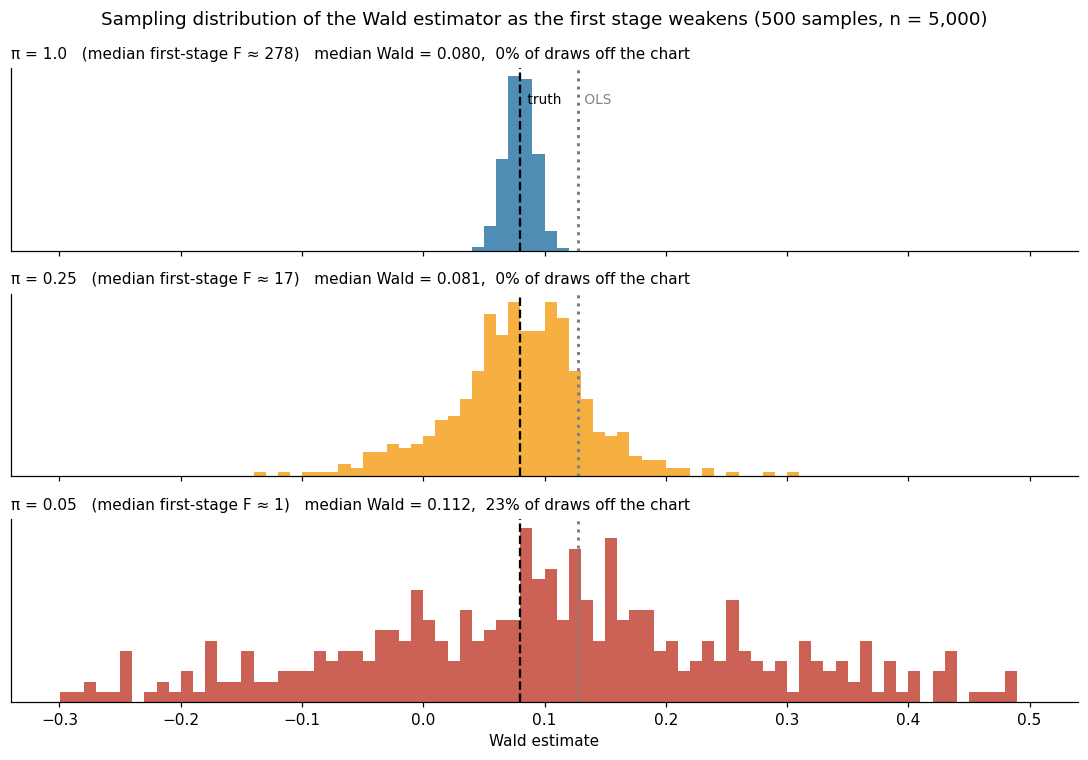

In [7]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
bins = np.linspace(-0.3, 0.5, 81)
for ax, (pi, c) in zip(axes, [(1.0, "#2471a3"), (0.25, "#f39c12"), (0.05, "#c0392b")]):
    draws, Fs = [], []
    for s in rng.integers(0, 1e9, 500):
        d = simulate(n=5_000, pi=pi, seed=int(s))
        draws.append(wald(d))
        Fs.append(smf.ols("S ~ Z", data=d).fit().tvalues["Z"] ** 2)
    draws = np.array(draws)
    outside = np.mean((draws < -0.3) | (draws > 0.5))
    ax.hist(draws[(draws >= -0.3) & (draws <= 0.5)], bins=bins, color=c, alpha=0.8)
    ax.axvline(0.08, color="k", ls="--", lw=1.5)
    ax.axvline(b_ols_sim, color="gray", ls=":", lw=2)
    ax.set_title(f"π = {pi}   (median first-stage F ≈ {np.median(Fs):.0f})   median Wald = {np.median(draws):.3f},"
                 f"  {outside:.0%} of draws off the chart", fontsize=10, loc="left")
    ax.set_yticks([])
axes[0].text(0.082, axes[0].get_ylim()[1] * 0.8, " truth", fontsize=9)
axes[0].text(b_ols_sim + 0.002, axes[0].get_ylim()[1] * 0.8, " OLS", fontsize=9, color="gray")
axes[-1].set_xlabel("Wald estimate")
fig.suptitle("Sampling distribution of the Wald estimator as the first stage weakens (500 samples, n = 5,000)")
plt.tight_layout(); plt.show()

Two things happen as $\pi \to 0$: the distribution gets **very wide** (fat tails), and its center drifts **toward OLS**. A weak IV does not just give noisy estimates; it gives estimates biased in the same direction as the problem you were trying to fix.

---
## Part 3. Angrist & Krueger (1991): quarter of birth as a natural experiment

### 3.1 The institutional story (this *is* the identification strategy)

Two rules interact:

1. **School-entry rules.** Most districts required a child to turn 6 by January 1 of the school year. So a child born in **January** enters first grade almost a full year *older* than a child born in **December**. (AK: 6.45 vs. 6.07 years old at entry.)
2. **Compulsory-schooling laws.** Most states let students leave school on their **16th (or 17th) birthday**.

Put them together: a January-born student reaches 16 after fewer completed years of school than a December-born classmate. If some students want to drop out as soon as the law allows, the **January-born can leave with less schooling**.

So quarter of birth (QOB) shifts schooling for *reasons unrelated to ability*... as long as your birthday is unrelated to your ability and family background. That "as long as" is the exclusion/independence assumption, and we'll come back to it.

**Mapping to the IV slides:**

| IV concept | AK91 |
|---|---|
| Treatment $D$ / $S$ | years of completed schooling |
| Outcome $Y$ | log weekly wage (1979) |
| Instrument $Z$ | born in Q1 (vs. Q2–Q4); later, QOB × year-of-birth dummies |
| Source of variation | school-start-age rules × compulsory-attendance laws |
| Compliers | men who would have dropped out at the legal age if allowed |

### 3.2 Data

We use Angrist's public extract of the **1980 Census 5% PUMS**: men born 1930–1939 with positive earnings, **N = 329,509**. This is exactly the sample behind **Table III, Panel B** and **Table V** of the paper, so we can check our numbers against the published ones. (Men were 40–49 in 1980; AK use this group because the age–earnings profile is flat at those ages, so being a few months older doesn't mechanically raise wages.)

The file is hosted in the `masteringmetrics` repository (a copy of the Angrist Data Archive extract).

In [8]:
import urllib.request, pyreadr
from pathlib import Path

DATA_URL = "https://raw.githubusercontent.com/jrnold/masteringmetrics/master/masteringmetrics/data/ak91.rda"
LOCAL = Path("ak91.rda")
if not LOCAL.exists():
    urllib.request.urlretrieve(DATA_URL, LOCAL)

ak = pyreadr.read_r(LOCAL)["ak91"]
ak["qob"] = ak["qob"].astype(int)
ak["q1"]  = (ak["qob"] == 1).astype(int)
# lnw: log weekly wage | s: years of schooling | yob, qob: year and quarter of birth
# sob: state of birth | age: age in quarters of a year on Census day
print(ak.shape)
ak.describe().T

(329509, 7)


,count,mean,std,min,25%,50%,75%,max
lnw,329509.0000,5.8999,0.6788,-2.3418,5.6365,5.9525,6.2574,10.5321
s,329509.0000,12.7699,3.2812,0.0000,12.0000,12.0000,15.0000,20.0000
yob,329509.0000,1934.6028,2.9050,1930.0000,1932.0000,1935.0000,1937.0000,1939.0000
qob,329509.0000,2.5064,1.1119,1.0000,2.0000,3.0000,3.0000,4.0000
sob,329509.0000,30.6926,14.2184,1.0000,19.0000,34.0000,42.0000,56.0000
age,329509.0000,45.0206,2.9207,40.2500,42.5000,45.0000,47.5000,50.0000
q1,329509.0000,0.2479,0.4318,0.0000,0.0000,0.0000,0.0000,1.0000


### 3.3 The first stage in a picture (AK Figure I)

Average schooling by year × quarter of birth. Each point is labeled with its quarter.

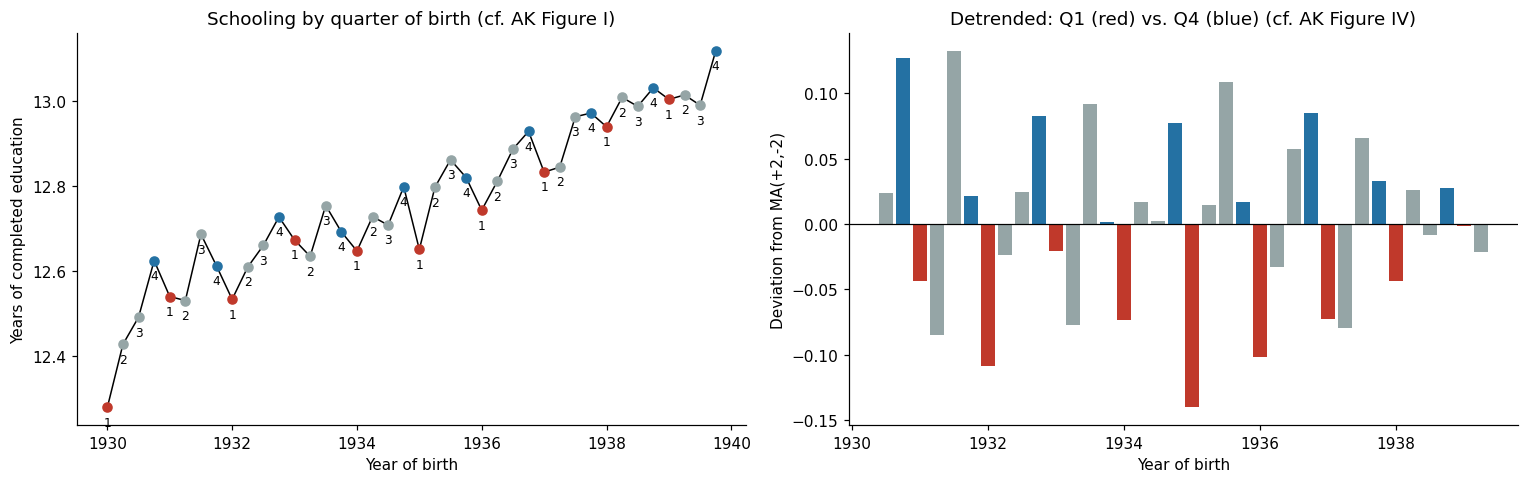

In [9]:
cells = (ak.groupby(["yob", "qob"])
           .agg(s=("s", "mean"), lnw=("lnw", "mean"), n=("s", "size"))
           .reset_index())
cells["t"] = cells.yob + (cells.qob - 1) / 4          # time index in quarters

# detrend as in AK: subtract the average of the 2 preceding and 2 following quarters, MA(+2,-2)
for v in ["s", "lnw"]:
    x = cells[v]
    cells[v + "_dt"] = x - (x.shift(2) + x.shift(1) + x.shift(-1) + x.shift(-2)) / 4

colors = {1: "#c0392b", 2: "#95a5a6", 3: "#95a5a6", 4: "#2471a3"}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(cells.t, cells.s, color="k", lw=1)
for _, r in cells.iterrows():
    ax[0].scatter(r.t, r.s, color=colors[r.qob], s=35, zorder=3)
    ax[0].annotate(int(r.qob), (r.t, r.s), textcoords="offset points", xytext=(0, -12), ha="center", fontsize=8)
ax[0].set(xlabel="Year of birth", ylabel="Years of completed education", title="Schooling by quarter of birth (cf. AK Figure I)")
ax[1].bar(cells.t, cells.s_dt, width=0.2, color=[colors[q] for q in cells.qob])
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(xlabel="Year of birth", ylabel="Deviation from MA(+2,-2)", title="Detrended: Q1 (red) vs. Q4 (blue) (cf. AK Figure IV)")
plt.tight_layout(); plt.show()

**Look for the saw-tooth.** Within almost every year, Q1 (red) is a local low and Q3/Q4 are local highs. That's the first stage: small (about a tenth of a year) but remarkably regular.

### 3.4 The reduced form in a picture (AK Figure V)

If schooling pays, and Q1 men have less schooling, Q1 men should also earn slightly less.

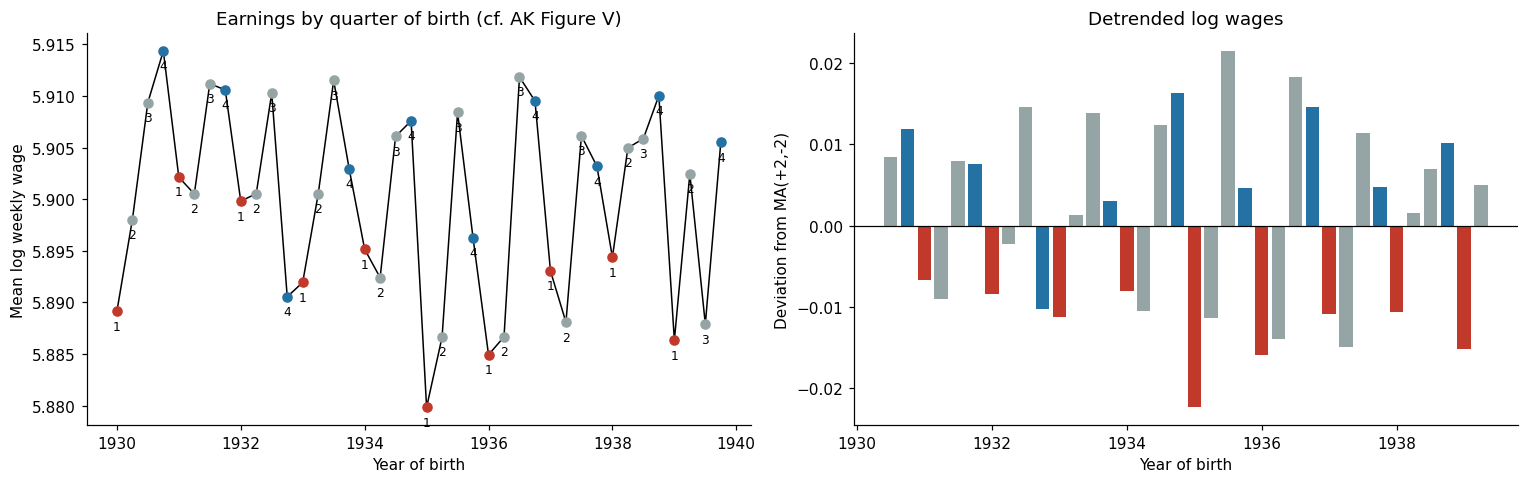

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(cells.t, cells.lnw, color="k", lw=1)
for _, r in cells.iterrows():
    ax[0].scatter(r.t, r.lnw, color=colors[r.qob], s=35, zorder=3)
    ax[0].annotate(int(r.qob), (r.t, r.lnw), textcoords="offset points", xytext=(0, -12), ha="center", fontsize=8)
ax[0].set(xlabel="Year of birth", ylabel="Mean log weekly wage", title="Earnings by quarter of birth (cf. AK Figure V)")
ax[1].bar(cells.t, cells.lnw_dt, width=0.2, color=[colors[q] for q in cells.qob])
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(xlabel="Year of birth", ylabel="Deviation from MA(+2,-2)", title="Detrended log wages")
plt.tight_layout(); plt.show()

The earnings saw-tooth is noisier. That's expected: the reduced form is the first stage (≈ 0.1 years) *times* a return of ≈ 0.1, so we're looking for a wage gap of roughly 1%.

### 3.5 Exercise: replicate Table III, Panel B (the Wald estimate)

Compare men born in **Q1** with men born in **Q2–Q4**. Published numbers (1980 Census, men born 1930–39):

| | Q1 | Q2–Q4 | Difference |
|---|---|---|---|
| ln(weekly wage) | 5.8916 | 5.9027 | −0.01110 (0.00274) |
| Education | 12.6881 | 12.7969 | −0.1088 (0.0132) |
| **Wald estimate** | | | **0.1020 (0.0239)** |
| OLS | | | 0.0709 (0.0003) |

In [11]:
tab = ak.groupby("q1")[["lnw", "s"]].mean()
rf_ak = tab.loc[1, "lnw"] - tab.loc[0, "lnw"]     # reduced form
fs_ak = tab.loc[1, "s"]   - tab.loc[0, "s"]       # first stage
wald_ak = rf_ak / fs_ak
ols_ak = smf.ols("lnw ~ s", data=ak).fit().params["s"]

print(tab.rename(index={0: "Q2-Q4", 1: "Q1"}).T)
print(f"\nReduced form (Q1 - rest)  : {rf_ak:.5f}")
print(f"First stage  (Q1 - rest)  : {fs_ak:.4f}")
print(f"Wald estimate             : {wald_ak:.4f}")
print(f"OLS                       : {ols_ak:.4f}")

q1    Q2-Q4      Q1
lnw  5.9027  5.8916
s   12.7969 12.6881

Reduced form (Q1 - rest)  : -0.01110
First stage  (Q1 - rest)  : -0.1088
Wald estimate             : 0.1020
OLS                       : 0.0709


Notice **both differences are negative** and the ratio is positive. The sign of the instrument doesn't matter; only the ratio does.

Now confirm that the Wald estimator *is* IV with a single binary instrument and no covariates (AK footnote 13), and get the standard error. We use conventional (homoskedastic) SEs to match the paper.

In [12]:
iv_wald = IV2SLS.from_formula("lnw ~ 1 + [s ~ q1]", data=ak).fit(cov_type="unadjusted")
print(f"IV estimate: {iv_wald.params['s']:.4f}  (SE {iv_wald.std_errors['s']:.4f})")

# Always check the first stage (lecture slide 21)
fs_reg = smf.ols("s ~ q1", data=ak).fit()
print(f"First stage: {fs_reg.params['q1']:.4f}  t = {fs_reg.tvalues['q1']:.2f}  F = {fs_reg.tvalues['q1']**2:.1f}")

IV estimate: 0.1020  (SE 0.0239)
First stage: -0.1088  t = -8.22  F = 67.6


**Discuss (2 min):** The Wald estimate (0.102) is *larger* than OLS (0.071). The ability-bias story in Part 1 predicted OLS would be too **high**. What could make IV larger than OLS?

Candidates worth naming: measurement error in schooling (attenuates OLS toward zero), heterogeneous returns (IV measures the return for a *specific* group, see 4.3), or a violation of the IV assumptions. AK lean toward the first; hold the other two in mind.

---
## Part 4. From Wald to 2SLS, and what can go wrong

### 4.1 IV is still "fitting a line through group means"

The Wald estimator uses one contrast: Q1 vs. the rest. But we have **40 groups** (10 birth years × 4 quarters). AK's Table V uses the full set of **QOB × YOB** interactions as instruments while controlling for year of birth. That sounds complicated, but it has the same geometry as Figure 2(b):

> With a full set of group dummies as instruments, **2SLS = a (weighted) regression of group-mean wages on group-mean schooling**.

With year-of-birth controls, only *within-year* differences across quarters are used. The figure plots the 40 group means after removing each birth year's average.

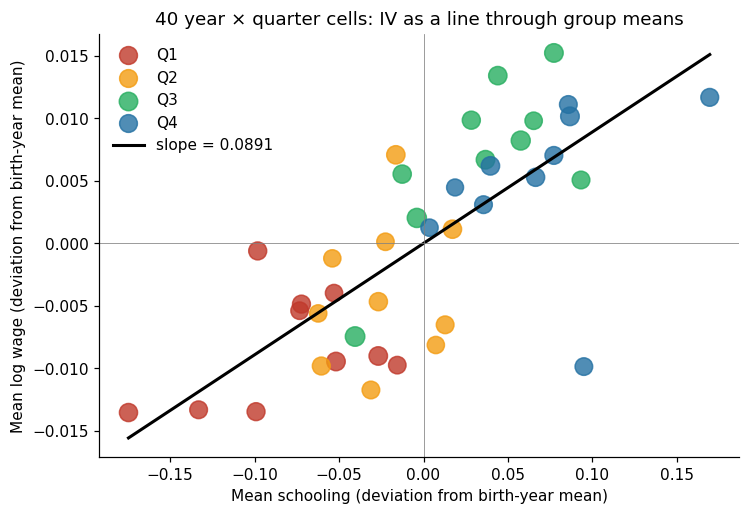

In [13]:
w = cells.copy()
for v in ["s", "lnw"]:
    w[v + "_w"] = w[v] - w.groupby("yob")[v].transform(lambda x: np.average(x, weights=w.loc[x.index, "n"]))
grouped = smf.wls("lnw_w ~ s_w - 1", data=w, weights=w.n).fit()

fig, ax = plt.subplots(figsize=(7.5, 5))
for q in [1, 2, 3, 4]:
    d = w[w.qob == q]
    ax.scatter(d.s_w, d.lnw_w, s=d.n / 60, color=["#c0392b", "#f39c12", "#27ae60", "#2471a3"][q - 1], alpha=0.8, label=f"Q{q}")
xs = np.linspace(w.s_w.min(), w.s_w.max(), 10)
ax.plot(xs, grouped.params["s_w"] * xs, "k", lw=2, label=f"slope = {grouped.params['s_w']:.4f}")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set(xlabel="Mean schooling (deviation from birth-year mean)", ylabel="Mean log wage (deviation from birth-year mean)",
       title="40 year × quarter cells: IV as a line through group means")
ax.legend(frameon=False); plt.show()

### Exercise 4.1: replicate Table V, columns (1) and (2)

Published: **OLS 0.0711 (0.0003)** and **TSLS 0.0891 (0.0161)**, both with 9 year-of-birth dummies.

Build the 30 excluded instruments: an indicator for each combination of **quarter ∈ {1, 2, 3}** and **birth year ∈ {1930, …, 1939}**. (Why not Q4? Because Q4 × each year is already spanned by the year dummies once Q1–Q3 are in: the dummy trap.)

In [14]:
years = range(1930, 1940)
inst = []
for q in [1, 2, 3]:
    for y in years:
        name = f"q{q}_y{y}"
        ak[name] = ((ak.qob == q) & (ak.yob == y)).astype(float)
        inst.append(name)

yob_d = pd.get_dummies(ak.yob, prefix="yob", drop_first=True).astype(float)
X = sm.add_constant(yob_d)                                   # included exogenous controls

ols_v1  = sm.OLS(ak.lnw, pd.concat([X, ak.s], axis=1)).fit()
tsls_v2 = IV2SLS(ak.lnw, X, ak.s, ak[inst]).fit(cov_type="unadjusted")
print(f"Col (1) OLS : {ols_v1.params['s']:.4f} ({ols_v1.bse['s']:.4f})")
print(f"Col (2) TSLS: {tsls_v2.params['s']:.4f} ({tsls_v2.std_errors['s']:.4f})")

Col (1) OLS : 0.0711 (0.0003)
Col (2) TSLS: 0.0891 (0.0161)


Compare the TSLS coefficient with the slope in the 40-cell figure above. Same number.

**Now check the first stage** (slide 21: "always check the first stage"). With many instruments, the relevant statistic is the joint $F$ on the excluded instruments.

In [15]:
def first_stage_F(instruments):
    unrestricted = sm.OLS(ak.s, pd.concat([X, ak[instruments]], axis=1)).fit()
    restricted   = sm.OLS(ak.s, X).fit()
    F, p, k = unrestricted.compare_f_test(restricted)
    return F, int(k)

ak["q2"] = (ak.qob == 2).astype(float); ak["q3"] = (ak.qob == 3).astype(float)
for label, z in [("Q1 only (Wald-style)", ["q1"]),
                 ("Q1, Q2, Q3", ["q1", "q2", "q3"]),
                 ("QOB x YOB (30)", inst)]:
    F, k = first_stage_F(z)
    est = IV2SLS(ak.lnw, X, ak.s, ak[z]).fit(cov_type="unadjusted")
    print(f"{label:22s}  k = {k:2d}   first-stage F = {F:6.1f}   TSLS = {est.params['s']:.4f} ({est.std_errors['s']:.4f})")

Q1 only (Wald-style)    k =  1   first-stage F =   64.7   TSLS = 0.1049 (0.0246)
Q1, Q2, Q3              k =  3   first-stage F =   32.3   TSLS = 0.1053 (0.0201)
QOB x YOB (30)          k = 30   first-stage F =    4.9   TSLS = 0.0891 (0.0161)


**More instruments ≠ better.** Adding 27 extra instruments barely adds first-stage information, so the $F$ statistic collapses from ≈ 65 to ≈ 5. The usual rule of thumb (Staiger & Stock, 1997) asks for $F > 10$; slide 21's "$|t| > 3$" is the same idea for one instrument ($t^2 = F$). Recent work (Lee, McCrary, Moreira & Porter, 2022) argues that even $F=10$ is too lenient for reliable $t$-tests.

### ⏱ 4.2 Demo: Bound, Jaeger & Baker's placebo (if time)

Bound, Jaeger & Baker (1995, *JASA*) asked: what if we replace real quarter of birth with a **randomly generated** quarter of birth? A fake instrument has *no* true first stage, so a sound procedure should return garbage with huge standard errors. Let's see.

In [16]:
def tsls_yob_fe(y, x, Z, groups):
    # 2SLS with birth-year fixed effects, via within-year demeaning (fast)
    dm = lambda a: (pd.DataFrame(a) - pd.DataFrame(a).groupby(groups).transform("mean")).to_numpy()
    yd, xd, Zd = dm(y).ravel(), dm(x).ravel(), dm(Z)
    xhat = Zd @ np.linalg.lstsq(Zd, xd, rcond=None)[0]
    b = (xhat @ yd) / (xhat @ xd)
    e = yd - b * xd
    se = np.sqrt(e @ e / (len(yd) - Zd.shape[1] - 10) / (xhat @ xhat))
    return b, se

g = ak.yob.to_numpy()
rng = np.random.default_rng(521)
fake = []
for r in range(50):
    fq = rng.integers(1, 5, len(ak))                          # random "quarter of birth"
    Zf = np.column_stack([(fq == q) & (g == y) for q in [1, 2, 3] for y in years]).astype(float)
    fake.append(tsls_yob_fe(ak.lnw.to_numpy(), ak.s.to_numpy(), Zf, g))
fake = np.array(fake)

print(f"Real instruments          : {tsls_v2.params['s']:.4f}")
print(f"OLS                       : {ols_v1.params['s']:.4f}")
print(f"Fake instruments, median  : {np.median(fake[:, 0]):.4f}")
print(f"Share of fake estimates 'significant' at 5%: {(np.abs(fake[:, 0] / fake[:, 1]) > 1.96).mean():.0%}")

Real instruments          : 0.0891
OLS                       : 0.0711
Fake instruments, median  : 0.0711
Share of fake estimates 'significant' at 5%: 52%


With random instruments, 2SLS lands right on **OLS**, and the conventional standard errors say it's "significant" about half the time. When instruments are weak, 2SLS inherits the bias of OLS and hides it behind reassuring standard errors. This critique is why the 30- and 180-instrument columns of AK91 are now read with caution, while the **simple Wald estimate** (one strong instrument, $F \approx 68$) holds up well.

### 4.3 Exclusion and independence: the assumptions you can't test

The weak-IV problem is statistical. The deeper question is whether birthdays are really unrelated to earnings except through schooling. Recall Exercise 2.2: a violation of size $\gamma$ biases Wald by $\gamma / \pi$.

**Exercise.** Suppose being born in Q1 lowers weekly wages *directly* by just 0.3% (e.g. through some channel other than schooling). How much would that move the Wald estimate?

In [17]:
gamma = -0.003                        # direct effect of Q1 on log wages
bias  = gamma / fs_ak
print(f"Bias = gamma / first stage = {bias:.4f}")
print(f"Wald estimate {wald_ak:.4f}  ->  corrected {wald_ak - bias:.4f}")

Bias = gamma / first stage = 0.0276
Wald estimate 0.1020  ->  corrected 0.0744


A direct effect of 0.3% is invisible to the naked eye, yet it moves the estimate by about 0.03, roughly the whole gap between IV and OLS. So the credibility of AK91 rests on arguing that no such channel exists. How do they argue it (Section III)?

| Possible channel from QOB to wages | AK's response | Later literature |
|---|---|---|
| **Age**: Q1 men are a few months older | Use 40–49 year-olds (flat age–earnings profile); Table V cols (3)–(4) add age and age² | — |
| **Relative age / maturity** at school entry | If older entrants do better, IV is biased *downward* | Bedard & Dhuey (2006, *QJE*) find lasting relative-age effects on test scores |
| **Family background** varies by season of birth | Cite evidence that birth seasonality is similar across groups | Buckles & Hungerman (2013, *REStat*): winter births are disproportionately to teen, unmarried, and less-educated mothers |
| — | **Falsification test**: QOB should not predict wages for college graduates, whose schooling isn't constrained by the law. It doesn't. | |

The falsification test is the most persuasive move in the paper, and it's a template you should steal: find a subgroup where the first stage should be zero and show the reduced form is zero there too.

### ⏱ 4.4 Who are the compliers? (LATE, lecture slide 11)

IV recovers the effect for people **moved by the instrument**. Here, that's men who would have left school at the legal dropout age if they could. We can see *where* in the schooling distribution the instrument bites: compare $P(S \ge k)$ between Q2–Q4 and Q1 for each $k$.

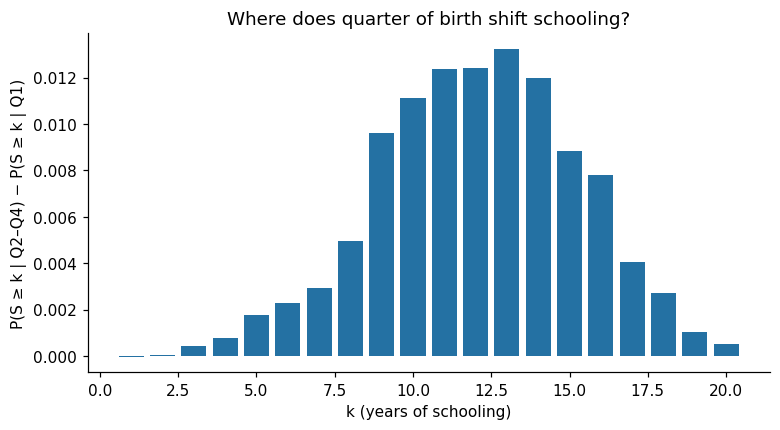

Sum of the bars = first stage: 0.1088  (compare 0.1088)


In [18]:
ks = range(1, 21)
gap = [(ak.loc[ak.q1 == 0, "s"] >= k).mean() - (ak.loc[ak.q1 == 1, "s"] >= k).mean() for k in ks]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(ks), gap, color="#2471a3")
ax.set(xlabel="k (years of schooling)", ylabel="P(S ≥ k | Q2–Q4) − P(S ≥ k | Q1)",
       title="Where does quarter of birth shift schooling?")
plt.show()
print(f"Sum of the bars = first stage: {sum(gap):.4f}  (compare {-fs_ak:.4f})")

The bars sum to the first stage: each bar says how many people Q1 pushed below $k$ years. The weights concentrate around 9–14 years, the high-school margin. So the Wald estimate is (roughly) the **return to schooling for men at the compulsory-schooling margin**, not the return to a college degree. That's the *L* in LATE.

But notice the bars at 13–16 are not zero. If compulsory schooling were the *only* channel, QOB shouldn't shift post-secondary schooling. AK's own Table I finds small but significant Q1 effects on college graduation. Worth raising in your reading notes.

---
## Part 5. Wrap-up: the four reading-note questions, for AK91

Fill these in (one or two sentences each). They mirror the structure of your weekly reading notes.

1. **Identifying assumption, in words (about people, not equations):**
   *...*
2. **The example:** treatment, outcome, comparison group, source of variation:
   *...*
3. **Where it would break:** which assumption is most likely to fail, and what would you observe if it did?
   *...*
4. **Your question:** what's still unclear, or what seemed to contradict the RCT readings?
   *...*

### Takeaways

- The **Wald estimator** = reduced form ÷ first stage. With one binary instrument and no covariates, it *is* IV.
- IV fixes endogeneity by **throwing away** all variation in the treatment except the part driven by the instrument. Graphically: fit a line through group means, not through the individual cloud.
- **Relevance** is testable (first-stage $F$). **Exclusion and independence** are not; they're defended with institutional knowledge and falsification tests.
- Violations of exclusion are **divided by the first stage**. Weak instruments magnify small sins and pull 2SLS toward OLS.
- IV estimates a **LATE**: the effect for compliers, here men on the margin of dropping out.

### References
- Angrist, J. D. & Krueger, A. B. (1991). Does compulsory school attendance affect schooling and earnings? *QJE* 106(4), 979–1014.
- Bound, J., Jaeger, D. A. & Baker, R. M. (1995). Problems with instrumental variables estimation when the correlation between the instruments and the endogenous explanatory variable is weak. *JASA* 90(430), 443–450.
- Buckles, K. S. & Hungerman, D. M. (2013). Season of birth and later outcomes: Old questions, new answers. *REStat* 95(3), 711–724.
- Bedard, K. & Dhuey, E. (2006). The persistence of early childhood maturity: International evidence of long-run age effects. *QJE* 121(4), 1437–1472.
- Staiger, D. & Stock, J. H. (1997). Instrumental variables regression with weak instruments. *Econometrica* 65(3), 557–586.
- Lee, D. S., McCrary, J., Moreira, M. J. & Porter, J. (2022). Valid t-ratio inference for IV. *AER* 112(10), 3260–3290.
- Wald, A. (1940). The fitting of straight lines if both variables are subject to error. *Annals of Mathematical Statistics* 11(3), 284–300.